In [1]:
import numpy as np
# from scipy.fft import fft2, ifft2, fftshift, ifftshift
# from scipy.special import j0

from ekarus.e2e.devices.pyramid_wfs import PyramidWFS

from arte.utils.zernike_generator import ZernikeGenerator
from arte.types.mask import CircularMask

# def get_circular_mask(mask_shape, mask_radius, mask_center=None):
#     H,W = mask_shape
#     if mask_center is None:
#         mask_center = (W/2-0.5,H/2-0.5)
#     dist = lambda x,y: np.sqrt((x-mask_center[0])**2+(y-mask_center[1])**2)
#     mask = np.fromfunction(lambda i,j: dist(j,i) >= mask_radius, [H,W])
#     mask = (mask).astype(bool)
#     return mask


[XuPy] GPU Acceleration not available. 
       Fallback to NumPy instead.


In [2]:
Npix = 120
sensorLambda = 750e-9
detector_size = Npix
oversampling = 4
pupilSizeInPixels = Npix
pupilSizeInM = 2
rebin = oversampling*pupilSizeInPixels/detector_size
subapertureSize = 40
subapPixSep = 60

apex_angle = 2*np.pi*sensorLambda/pupilSizeInM*112#220

pupil = CircularMask((Npix,Npix), maskRadius=Npix//2, maskCenter=(Npix/2,Npix/2))

pyr = PyramidWFS(apex_angle, oversampling, sensorLambda)
zg = ZernikeGenerator(pupil)

In [3]:
def create_field_from_zernike_coefficients(mask, noll_ids:tuple, amplitudes:tuple):
    """
    Create an electric field input corresponding to a Zernike aberration.
    
    :param mask: CircularMask object defining the pupil
    :param noll_ids: tuple of Zernike noll number
    :param amplitudes: Amplitude or tuple of amplitudes
                       of the Zernike aberration in radians
    
    :return: input electric field as a numpy complex array
    """
    phase_mask = project_zernike_on_mask(mask, noll_ids, amplitudes)
    return mask.asTransmissionValue() * np.exp(1j * phase_mask)


def project_zernike_on_mask(mask, noll_ids:tuple, amplitudes:tuple):
    """
    Create a linear combination of Zernikes on a mask.
    
    :param mask: CircularMask object defining the pupil
    :param noll_ids: tuple of Zernike noll number
    :param amplitudes: Amplitude or tuple of amplitudes
                       of the Zernike aberration in radians
    
    :return: zernike combination
    """
    zg = ZernikeGenerator(mask)

    if isinstance(noll_ids,int):
        amp = amplitudes
        noll = noll_ids
        zern = amp * zg.getZernike(noll)
    else:
        amplitudes *= np.ones_like(noll_ids)
        zern = np.zeros(mask.mask().shape)
        for amp,noll in zip(amplitudes, noll_ids):
            zern += amp * zg.getZernike(noll)

    return zern

1.190589998257144e-07 0.3697754635782306


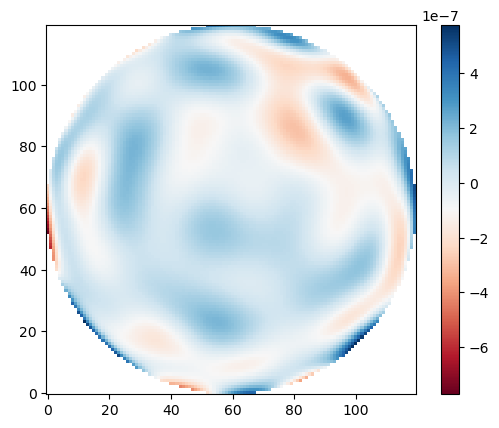

In [4]:
import matplotlib.pyplot as plt

noll_ids = np.arange(2,100)
amplitudes = np.random.randn(len(noll_ids))/np.sqrt(np.sqrt(noll_ids))*3e-8
random_phase = project_zernike_on_mask(pupil, noll_ids, amplitudes)
rms = np.sqrt(np.mean(random_phase[pupil.asTransmissionValue().astype(bool)]**2))
SR = np.exp(-(rms/sensorLambda*2*np.pi)**2)
print(rms,SR)

plt.figure()
plt.imshow(np.ma.masked_array(random_phase,mask=pupil.mask()),origin='lower',cmap='RdBu')
plt.colorbar()

In [5]:
# Array of padded zernike modes
Nmodes = 400
zern_modes = np.zeros([Nmodes,Npix,Npix])

for i in range(Nmodes):
    zern_modes[i] = project_zernike_on_mask(pupil, i+2, 1) * pupil.asTransmissionValue()

In [6]:
pyr.set_modulation_angle(2)
lambdaOverD = sensorLambda/pupilSizeInM
# pyr._modNsteps *= 4

Modulating 2 [lambda/D] with 12 modulation steps


In [7]:
def pad_and_fft(arr, oversampling:int=oversampling, inverse:bool=False, crop:bool=True):
    Ny, Nx = arr.shape
    pad_y = int(np.round((oversampling - 1) / 2 * Ny))
    pad_x = int(np.round((oversampling - 1) / 2 * Nx))
    padded = np.pad(arr, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0.0)
    if inverse:
        fft_vec = np.fft.ifft2(np.fft.ifftshift(padded)) #np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(padded)))
    else:
        fft_vec = np.fft.fftshift(np.fft.fft2(padded))
    if crop:
        return fft_vec[pad_y:pad_y + Ny, pad_x:pad_x + Nx]
    else:
        return fft_vec


def get_modulation_intensity(pyr, input_field, lambdaOverD, oversampling:int=oversampling):
    """
    Compute the GSC signal omega from the complex input field.
    """
    mul = 3
    tiltX, tiltY = pyr._get_XY_tilt_planes(input_field.shape)
    alpha_pix = pyr.modulationAngleInLambdaOverD * (2 * np.pi)
    phi_vec = (2 * np.pi) * np.arange(pyr._modNsteps*mul) / (pyr._modNsteps*mul)
    intensity = np.zeros(input_field.shape, dtype=np.float64)
    phase_delay = pyr.pyramid_phase_delay(input_field.shape) / lambdaOverD

    for phi in phi_vec:
        tilt = tiltX * np.cos(phi) + tiltY * np.sin(phi)
        tilted_input = input_field * np.exp(1j * tilt * alpha_pix, dtype=np.complex128)
        focal_field = np.fft.fftshift(pad_and_fft(tilted_input, oversampling=oversampling))
        delayed_focal = focal_field * np.exp(1j * phase_delay, dtype=np.complex128)
        intensity += np.abs(delayed_focal)**2 / (pyr._modNsteps*mul)
    intensity = np.fft.fftshift(intensity)
    total = np.sum(intensity)
    if total > 0:
        intensity /= total
    return intensity


def compute_impulse_response(omega, oversampling:int=oversampling):
    """
    Compute the impulse response corresponding to equation 13:
    IR = 2 * Im( conj(FFT(mask)) * FFT(mask * omega) )
    """
    Ny, Nx = omega.shape
    pad_y = int(np.round((oversampling - 1) / 2 * Ny))
    pad_x = int(np.round((oversampling - 1) / 2 * Nx))
    padded = np.pad(omega, ((pad_y, pad_y), (pad_x, pad_x)), 'constant', constant_values=0.0)
    pyramid_phase = pyr.pyramid_phase_delay(padded.shape) / lambdaOverD
    pyramid_mask = np.exp(1j*pyramid_phase,dtype=complex)
    mask_fft = np.fft.fft2(np.fft.ifftshift(pyramid_mask))
    masked_omega = pyramid_mask * padded
    masked_fft = np.fft.fft2(np.fft.ifftshift(masked_omega))
    ir = 2 * np.imag(np.conj(mask_fft) * masked_fft)
    ir = np.fft.fftshift(ir)
    return ir#/total_flux

In [8]:
# a=np.ones([8,8])
# a[1,1] = 0
# plt.figure()
# plt.imshow(a)

In [9]:
fft_zern_modes = np.zeros([zern_modes.shape[0],zern_modes.shape[1]*oversampling,zern_modes.shape[2]*oversampling],dtype=complex)
Ny, Nx = zern_modes.shape[1:]
pad_y = int(np.round((oversampling - 1) / 2 * Ny))
pad_x = int(np.round((oversampling - 1) / 2 * Nx))
for i in range(Nmodes):
    padded = np.pad(zern_modes[i]*pupil.asTransmissionValue(), ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0.0)
    fft_zern_modes[i] = np.fft.fft2(np.fft.fftshift(padded))

In [10]:
# plt.figure()
# plt.imshow(np.abs(fft_zern_modes[100])**2,origin='lower',cmap='turbo')
# plt.colorbar()

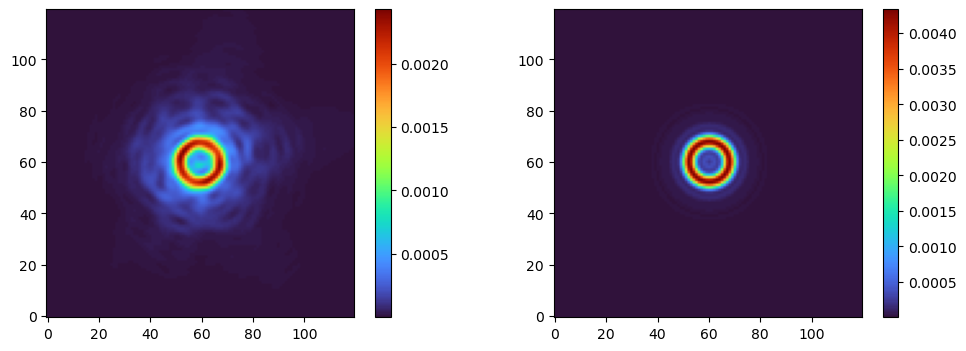

In [11]:

ref_ef = pupil.asTransmissionValue() * np.exp(1j*random_phase*0.0, dtype=complex)
omega_ref = get_modulation_intensity(pyr, ref_ef, lambdaOverD)

in_ef = pupil.asTransmissionValue() * np.exp(1j*random_phase*(2*np.pi)/sensorLambda, dtype=complex)
omega = get_modulation_intensity(pyr, in_ef, lambdaOverD)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(omega,origin='lower',cmap='turbo')
plt.colorbar()
# plt.xlim([30,90])
# plt.ylim([30,90])
plt.subplot(1,2,2)
plt.imshow(omega_ref,origin='lower',cmap='turbo')
plt.colorbar()
# plt.xlim([30,90])
# plt.ylim([30,90])

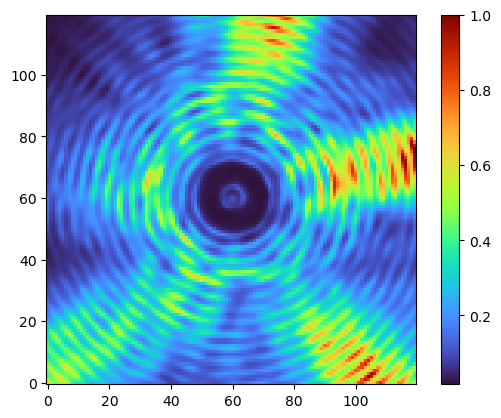

In [12]:
ratio = omega/omega_ref
# ratio = np.fft.ifft2( pad_and_fft(omega) / pad_and_fft(omega_ref))
ratio /= np.max(ratio)

plt.figure()
plt.imshow(np.abs(ratio),origin='lower',cmap='turbo')
plt.colorbar()

C:\Users\menes\AppData\Local\Temp\ipykernel_21216\1818453698.py:19: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(mtf/mtf_ref),origin='lower',cmap='jet')#,vmin=0,vmax=1)


(180.0, 300.0)

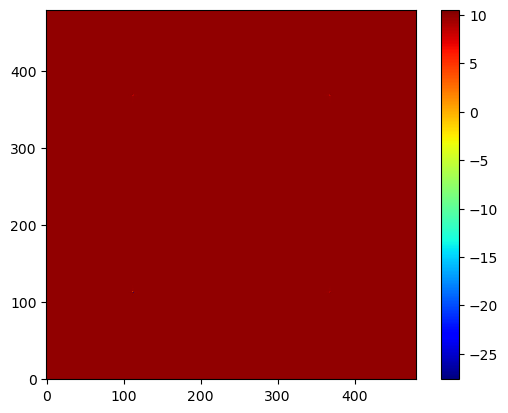

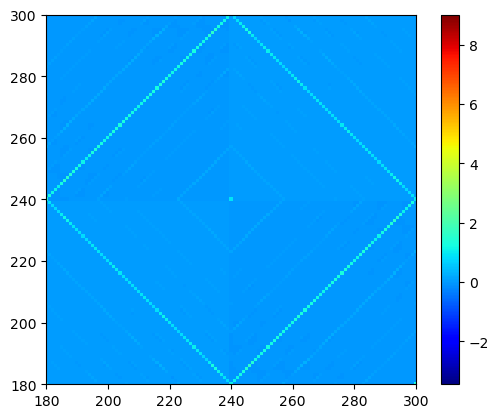

In [13]:
pyramid_phase = pyr.pyramid_phase_delay(in_ef.shape) / lambdaOverD
pyramid_mask = np.exp(1j*pyramid_phase,dtype=complex)

ir = compute_impulse_response(omega)
ir_ref = compute_impulse_response(omega_ref)

# ir = 2*np.imag( np.conj(np.fft.fft2(pyramid_mask)) * np.fft.fft2(omega*pyramid_mask))

plt.figure()
plt.imshow(np.fft.fftshift(np.log(ir-np.min(ir)+1e-12)),origin='lower',cmap='jet')#,vmin=34.6,vmax=35)
plt.colorbar()

# mtf = np.abs(np.fft.fft2(np.fft.ifftshift(ir)))
# mtf_ref = np.abs(np.fft.fft2(np.fft.ifftshift(ir_ref)))
mtf = np.abs(np.fft.ifftshift(pad_and_fft(ir)))
mtf_ref = np.abs(np.fft.ifftshift(pad_and_fft(ir_ref)))

plt.figure()
plt.imshow(np.log(mtf/mtf_ref),origin='lower',cmap='jet')#,vmin=0,vmax=1)
plt.colorbar()
plt.xlim([120*3/2,120*5/2])
plt.ylim([120*3/2,120*5/2])

# plt.figure()
# plt.imshow(np.abs(ir)/np.abs(ir_ref),origin='lower',cmap='turbo',vmin=0,vmax=1)
# plt.colorbar()
# plt.xlim([30,90])
# plt.ylim([30,90])


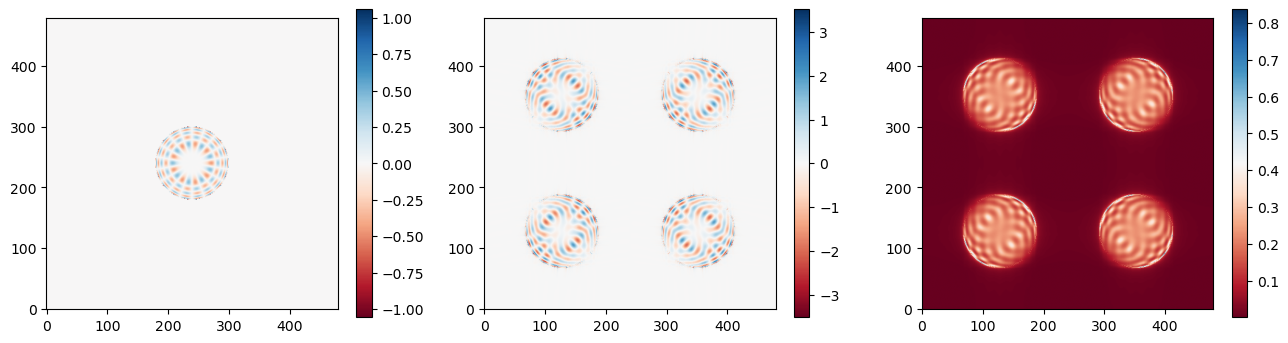

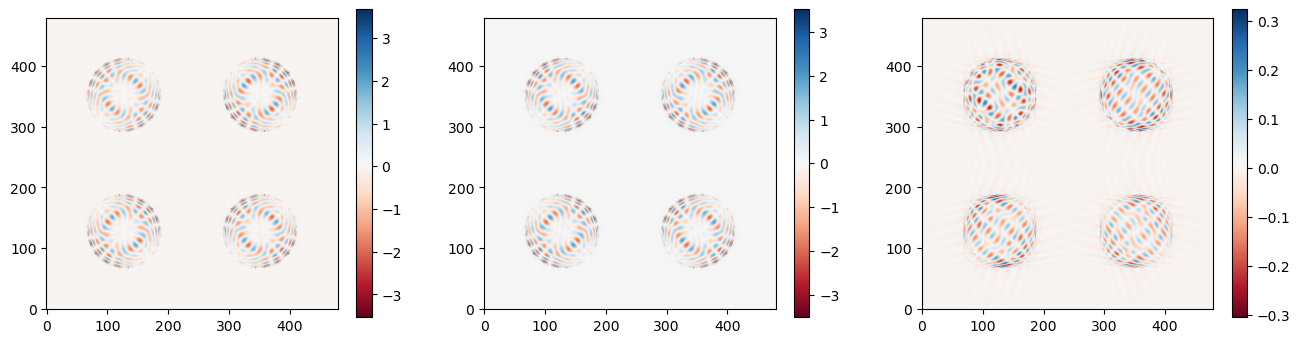

In [14]:
zern_phase = pupil.asTransmissionValue() * project_zernike_on_mask(pupil, 200, 0.2)
arr = pupil.asTransmissionValue() * np.exp(1j*zern_phase,dtype=np.complex128)    
Ny, Nx = arr.shape
pad_y = int(np.round((oversampling - 1) / 2 * Ny))
pad_x = int(np.round((oversampling - 1) / 2 * Nx))
# padded = np.pad(arr, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0.0)
padded = np.pad(zern_phase, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0.0)

dim = Npix * oversampling
image = np.fft.ifft2( np.fft.fft2(padded)/dim**2 * np.fft.fft2(ir)/dim**2 ) #( np.fft.fftshift(pad_and_fft(padded)) * np.fft.fftshift(pad_and_fft(ir)) ) #
image_ref = np.fft.ifft2( np.fft.fft2(padded)/dim**2 * np.fft.fft2(ir_ref)/dim**2 ) #( np.fft.fftshift(pad_and_fft(padded)) * np.fft.fftshift(pad_and_fft(ir_ref)) ) #
# image = np.fft.fftshift( np.fft.ifft2( pad_and_fft(padded) * pad_and_fft(ir) ) )#
# image_ref = np.fft.fftshift( np.fft.ifft2( pad_and_fft(padded) * pad_and_fft(ir_ref) ) ) #

# Perform the convolution using FFTs
fft_pupil = np.fft.fft2(np.fft.ifftshift(padded))
fft_ir = np.fft.fft2(np.fft.ifftshift(ir))
delta_I = np.fft.fftshift(np.fft.ifft2(fft_pupil * fft_ir).real)
delta_I /= np.sum(pupil.asTransmissionValue())

fft_ir_ref = np.fft.fft2(np.fft.ifftshift(ir_ref))
delta_I_ref = np.fft.fftshift(np.fft.ifft2(fft_pupil * fft_ir_ref).real)
delta_I_ref /= np.sum(pupil.asTransmissionValue())

pyr_image = pyr.get_intensity(arr,lambdaOverD)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(padded,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(delta_I_ref,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(pyr_image,origin='lower',cmap='RdBu')
plt.colorbar()

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(delta_I,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(delta_I_ref,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(delta_I-delta_I_ref,origin='lower',cmap='RdBu')
plt.colorbar()

In [15]:
# Precompute useful terms
ir_ref_fft = np.fft.fft2(np.fft.ifftshift(ir_ref))
conv_ref_mat = np.zeros_like(fft_zern_modes)
den = np.zeros(Nmodes,dtype=complex)
for i in range(Nmodes):
    prod = fft_zern_modes[i] * ir_ref_fft
    conv_ref_mat[i] = np.fft.ifft2(prod)
    res = conv_ref_mat[i].flatten()
    den[i] = np.sqrt(np.sum(res**2))

In [16]:
ogs = np.zeros(Nmodes)
ir_fft = np.fft.fft2(np.fft.ifftshift(ir))
for i in range(Nmodes):
    prod = fft_zern_modes[i] * ir_fft
    conv = np.fft.ifft2(prod) 
    res = conv.flatten()
    ref = conv_ref_mat[i].flatten()
    num = np.sqrt(np.sum(res*ref))
    ogs[i] = np.abs(num/den[i])**2

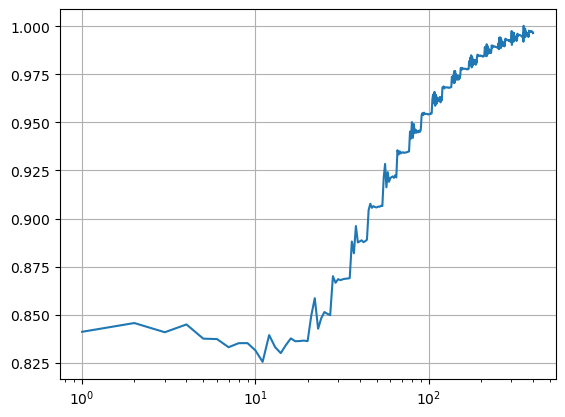

In [ ]:
x = np.arange(len(ogs))+1

plt.figure()
plt.semilogx(x,ogs)
plt.title('Optical gains')
plt.grid()